# 04 — Origin Classification with Transformer Embeddings (Frozen)

Mirrors the 02 and 03 pipelines using frozen sentence-transformer embeddings (e.g. SBERT-MiniLM, MPNet) as features for a classical classifier head. This is the "use a transformer, but don't fine-tune it" middle ground between TF-IDF (02) and full fine-tuning (04.1/04.2).

Main steps:

1. Load and filter to classes with ≥30 samples
2. Build preprocessing variants
3. Stratified 70/15/15 split
4. Grid search over preprocessing × transformer encoder × classifier, selected on validation Macro-F1
5. Best-model test evaluation and confusion matrix
6. Training-only resampling experiments

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sentence_transformers import SentenceTransformer
from transformers import AutoModel, AutoTokenizer

from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from nltk.stem import PorterStemmer, WordNetLemmatizer


## Load and filter the dataset

In [ ]:
DATA_PATH = 'Data/final_coffee_reviews.csv'
RANDOM_STATE = 42
MIN_SAMPLES_PER_CLASS = 100
BATCH_SIZE = 16
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Device:', DEVICE)
df.head(2)

Shape: (7585, 30)
Device: cuda


,URL,all_text,Rating,Roaster,Coffee Name,Roaster Location,Coffee Origin,Roast Level,Agtron,Est. Price,...,Who Should Drink It,Bottom Line,Combined_Acidity,Country_all,Country,aroma_text,flavor_text,acidity_text,body_text,combined_text
0,https://www.coffeereview.com/review/100-arabic...,87\nCaribeans\n100% Arabica Coffee from Puerto...,87.0,Caribeans,100% Arabica Coffee from Puerto Rico,"San Juan, Puerto Rico","Utuado, central Puerto Rico",Medium-Light,54/69,$17.00/8 ounces,...,NaN,Satisfying chocolate and nut notes nearly carr...,7.0,Puerto Rico; China,Puerto Rico,NaN,"bittersweet but balanced dark chocolate, dried...","bittersweet but balanced brisk, dry acidity",smooth but rather lean mouthfeel,"bittersweet but balanced dark chocolate, dried..."
1,https://www.coffeereview.com/review/100-arabic...,88\nWaka Coffee\n100% Arabica Freeze-Dried Col...,88.0,Waka Coffee,100% Arabica Freeze-Dried Colombian (Instant C...,"Los Angeles, California",Colombia,NaN,0/0,$10.99/8 single-serve packets,...,NaN,A appealing 100% Colombia coffee in instant fo...,7.0,Colombia,Colombia,NaN,"caramel-toned, richly sweet dark caramel, magn...",sweet-toned in structure with brisk acidity,smooth mouthfeel,"caramel-toned, richly sweet dark caramel, magn..."


In [3]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

coffee_terms_to_keep = {
    'acid', 'acidity', 'aromatic', 'berry', 'bright', 'buttery', 'caramel', 'cherry',
    'chocolate', 'citrus', 'clean', 'cocoa', 'creamy', 'crisp', 'dark', 'drying',
    'earthy', 'finish', 'flavor', 'floral', 'flower', 'fruit', 'fruity', 'honey',
    'jasmine', 'juicy', 'lemon', 'lime', 'mouthfeel', 'nectarine', 'nut', 'nutty',
    'orange', 'peach', 'rose', 'round', 'silky', 'smooth', 'spice', 'spicy', 'stone',
    'sweet', 'syrupy', 'tangerine', 'tea', 'tone', 'vanilla', 'winey'
}
stop_words = set(ENGLISH_STOP_WORDS) - coffee_terms_to_keep

misspelling_replacements = {
    r'\bchocolaty\b': 'chocolate',
    r'\bchoclate\b': 'chocolate',
    r'\bcitrussy\b': 'citrus',
    r'\bcitricy\b': 'citrus',
    r'\bcaramelly\b': 'caramel',
    r'\bcarmel\b': 'caramel',
    r'\bflorals\b': 'floral',
    r'\bfruity\b': 'fruit',
    r'\bnutty\b': 'nut',
    r'\bberries\b': 'berry',
}

phrase_replacements = {
    r'\bdark\s+chocolate\b': 'dark_chocolate',
    r'\bmilk\s+chocolate\b': 'milk_chocolate',
    r'\bbaking\s+chocolate\b': 'baking_chocolate',
    r'\bstone\s+fruit\b': 'stone_fruit',
    r'\borange\s+zest\b': 'orange_zest',
    r'\blemon\s+zest\b': 'lemon_zest',
    r'\bbrown\s+sugar\b': 'brown_sugar',
    r'\bred\s+apple\b': 'red_apple',
    r'\bpipe\s+tobacco\b': 'pipe_tobacco',
    r'\baromatic\s+wood\b': 'aromatic_wood',
    r'\btea\s+rose\b': 'tea_rose',
    r'\bdried\s+berry\b': 'dried_berry',
    r'\bchocolatey\b': 'chocolate',
    r'\bcocoa\s+toned\b': 'cocoa',
    r'\bcitrusy\b': 'citrus',
    r'\bberry\s+like\b': 'berry',
    r'\bberrylike\b': 'berry',
    r'\bfruit\s+toned\b': 'fruit',
    r'\bfloral\s+toned\b': 'floral',
    r'\bnut\s+toned\b': 'nut',
    r'\bcaramel\s+like\b': 'caramel',
    r'\bsweet\s+toned\b': 'sweet',
}


def minimal_raw_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.strip()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text


def apply_replacements(text: str) -> str:
    for pattern, replacement in misspelling_replacements.items():
        text = re.sub(pattern, replacement, text)
    for pattern, replacement in phrase_replacements.items():
        text = re.sub(pattern, replacement, text)
    return text


def normalize_text(text: str) -> str:
    text = minimal_raw_text(text).lower()
    text = apply_replacements(text)
    text = re.sub(r'[^a-z_\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def remove_domain_stopwords(text: str) -> str:
    tokens = [token for token in text.split() if token not in stop_words]
    return ' '.join(tokens)


def remove_domain_stopwords_and_stem(text: str) -> str:
    tokens = [stemmer.stem(token) for token in text.split() if token not in stop_words]
    return ' '.join(tokens)


def remove_domain_stopwords_and_lemmatize(text: str) -> str:
    tokens = [lemmatizer.lemmatize(token) for token in text.split() if token not in stop_words]
    return ' '.join(tokens)


## Build preprocessing variants

In [4]:
# Build text variants for transformer preprocessing ablation
df['text_raw_minimal'] = df['Blind Assessment'].fillna('').map(minimal_raw_text)
df['text_basic'] = df['Blind Assessment'].fillna('').map(normalize_text)
df['text_domain_stopwords'] = df['text_basic'].map(remove_domain_stopwords)
df['text_domain_stopwords_stemmed'] = df['text_basic'].map(remove_domain_stopwords_and_stem)
df['text_domain_stopwords_lemmatized'] = df['text_basic'].map(remove_domain_stopwords_and_lemmatize)
df['text_main'] = df['text_basic']

# Use the country label prepared in notebook 01
df['origin_country'] = df['Country'].astype('string').str.strip()
df['origin_country'] = df['origin_country'].replace('', pd.NA)

# Keep valid rows only
work = df[(df['text_raw_minimal'].str.len() >= 30) & (df['origin_country'].notna())].copy()

# Remove tiny classes for a stable baseline
counts = work['origin_country'].value_counts()
valid_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index
work = work[work['origin_country'].isin(valid_classes)].copy()

print('Rows after filtering:', len(work))
print('Num classes:', work['origin_country'].nunique())
work['origin_country'].value_counts().head(15)


Rows after filtering: 7437
Num classes: 25


origin_country
Ethiopia         1996
Colombia          988
Kenya             699
Guatemala         561
Indonesia         452
Costa Rica        373
Panama            354
United States     302
El Salvador       240
Brazil            200
Rwanda            176
Peru              130
Nicaragua         125
Honduras          123
Mexico            101
Name: count, dtype: Int64

## Dataset summary and class distribution

In [5]:
dataset_summary = pd.DataFrame({
    'metric': [
        'Rows in raw dataset',
        'Rows after preprocessing/filtering',
        'Unique origin classes after filtering',
        'Minimum samples per class',
        'Review date min',
        'Review date max',
    ],
    'value': [
        len(df),
        len(work),
        work['origin_country'].nunique(),
        MIN_SAMPLES_PER_CLASS,
        df['Review Date'].min(),
        df['Review Date'].max(),
    ]
})

dataset_summary

,metric,value
0,Rows in raw dataset,7585
1,Rows after preprocessing/filtering,7437
2,Unique origin classes after filtering,25
3,Minimum samples per class,30
4,Review date min,1997-02-01
5,Review date max,2026-03-01


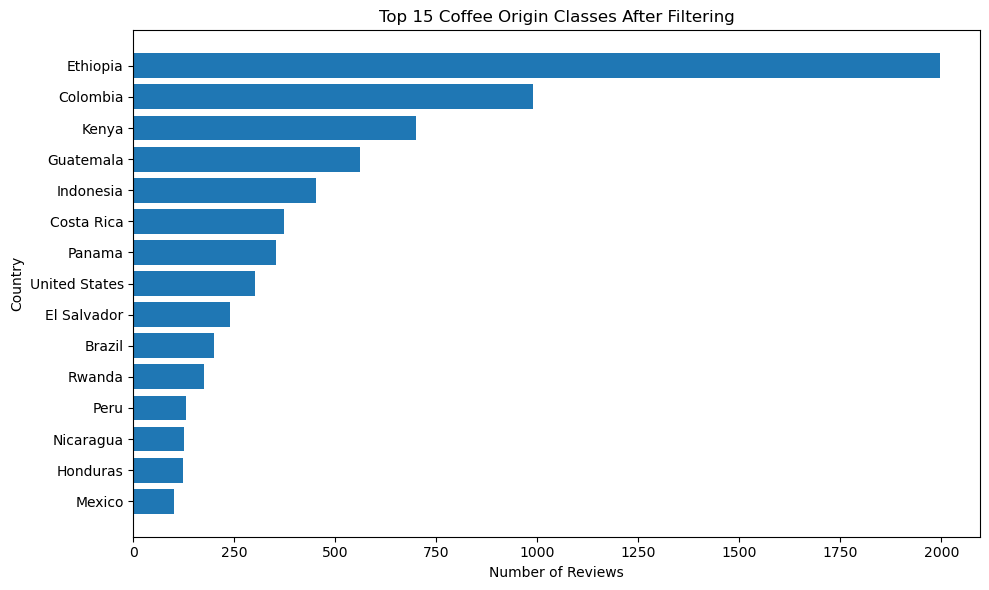

In [6]:
origin_counts = work['origin_country'].value_counts().head(15).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(origin_counts.index, origin_counts.values)
plt.xlabel('Number of Reviews')
plt.ylabel('Country')
plt.title('Top 15 Coffee Origin Classes After Filtering')
plt.tight_layout()
plt.show()

## Stratified 70/15/15 split

In [7]:
work = work.reset_index(drop=True)
y = work['origin_country']
row_idx = work.index

# 70/15/15 split (stratified)
train_idx, temp_idx, y_train, y_temp = train_test_split(
    row_idx, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print('Train:', len(train_idx), 'Val:', len(val_idx), 'Test:', len(test_idx))

Train: 5205 Val: 1116 Test: 1116


## Evaluation helper

In [8]:
def evaluate_predictions(y_true, y_pred, split_name='split'):
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    print(f'== {split_name} ==')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Balanced Accuracy: {bal_acc:.4f}')
    print(f'Precision: {p:.4f}')
    print(f'Recall:    {r:.4f}')
    print(f'F1-macro:  {f1:.4f}')
    return acc, bal_acc, p, r, f1

bert_tokenizer = None
bert_model = None
sbert_model = None


def load_bert_model(model_name='bert-base-uncased'):
    global bert_tokenizer, bert_model
    if bert_tokenizer is None or bert_model is None:
        bert_tokenizer = AutoTokenizer.from_pretrained(model_name)
        bert_model = AutoModel.from_pretrained(model_name).to(DEVICE)
        bert_model.eval()
    return bert_tokenizer, bert_model


def load_sbert_model(model_name='all-MiniLM-L6-v2'):
    global sbert_model
    if sbert_model is None:
        sbert_model = SentenceTransformer(model_name, device=DEVICE)
    return sbert_model


def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    masked_embeddings = last_hidden_state * mask
    summed = masked_embeddings.sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


def encode_texts_bert(texts, model_name='bert-base-uncased', batch_size=BATCH_SIZE):
    tokenizer, model = load_bert_model(model_name)
    all_embeddings = []
    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            batch = texts[start:start + batch_size]
            encoded = tokenizer(batch, padding=True, truncation=True, max_length=256, return_tensors='pt').to(DEVICE)
            outputs = model(**encoded)
            pooled = mean_pooling(outputs.last_hidden_state, encoded['attention_mask'])
            all_embeddings.append(pooled.cpu().numpy())
    return np.vstack(all_embeddings)


def encode_texts_sbert(texts, model_name='all-MiniLM-L6-v2', batch_size=BATCH_SIZE):
    model = load_sbert_model(model_name)
    return model.encode(texts, batch_size=batch_size, show_progress_bar=False, convert_to_numpy=True, normalize_embeddings=False)


def build_classifier(model_name, c_value, feature_reduction='none'):
    steps = [('scaler', StandardScaler())]
    if feature_reduction == 'pca_50':
        steps.append(('pca', PCA(n_components=50, random_state=RANDOM_STATE)))

    if model_name == 'Logistic Regression':
        steps.append(('clf', LogisticRegression(
            C=c_value,
            max_iter=5000,
            solver='liblinear',
            class_weight='balanced',
            multi_class='ovr',
            random_state=RANDOM_STATE,
        )))
        return Pipeline(steps)
    if model_name == 'Linear SVM':
        steps.append(('clf', LinearSVC(
            C=c_value,
            class_weight='balanced',
            dual='auto',
            max_iter=10000,
            random_state=RANDOM_STATE,
        )))
        return Pipeline(steps)
    raise ValueError(f'Unknown classifier: {model_name}')


def encode_transformer_split(embedding_name, train_texts, val_texts, test_texts):
    if embedding_name == 'BERT':
        return (
            encode_texts_bert(train_texts),
            encode_texts_bert(val_texts),
            encode_texts_bert(test_texts),
        )
    if embedding_name == 'Sentence-BERT':
        return (
            encode_texts_sbert(train_texts),
            encode_texts_sbert(val_texts),
            encode_texts_sbert(test_texts),
        )
    raise ValueError(f'Unknown embedding: {embedding_name}')


## Hyperparameter grid: preprocessing × encoder × classifier

In [9]:
preprocessing_variants = {
    'Raw text / punctuation preserved': 'text_raw_minimal',
    'Basic normalization': 'text_basic',
    'Domain stopword removal': 'text_domain_stopwords',
    'Domain stopword removal + stemming': 'text_domain_stopwords_stemmed',
    'Domain stopword removal + lemmatization': 'text_domain_stopwords_lemmatized',
}

ablation_results = []
best_preprocessing_name = None
best_text_column = None
best_preprocessing_val_f1 = -1

for variant_name, column_name in preprocessing_variants.items():
    X_train_variant = work.loc[train_idx, column_name].tolist()
    X_val_variant = work.loc[val_idx, column_name].tolist()
    X_test_variant = work.loc[test_idx, column_name].tolist()

    X_train_vec, X_val_vec, X_test_vec = encode_transformer_split('Sentence-BERT', X_train_variant, X_val_variant, X_test_variant)
    ablation_model = build_classifier('Linear SVM', 1.0, feature_reduction='none')
    ablation_model.fit(X_train_vec, y_train)
    y_val_pred_variant = ablation_model.predict(X_val_vec)
    y_test_pred_variant = ablation_model.predict(X_test_vec)

    val_acc = accuracy_score(y_val, y_val_pred_variant)
    val_bal_acc = balanced_accuracy_score(y_val, y_val_pred_variant)
    val_p, val_r, val_f1, _ = precision_recall_fscore_support(y_val, y_val_pred_variant, average='macro', zero_division=0)
    test_acc = accuracy_score(y_test, y_test_pred_variant)
    test_bal_acc = balanced_accuracy_score(y_test, y_test_pred_variant)
    test_p, test_r, test_f1, _ = precision_recall_fscore_support(y_test, y_test_pred_variant, average='macro', zero_division=0)

    ablation_results.append({
        'preprocessing_variant': variant_name,
        'text_column': column_name,
        'val_accuracy': val_acc,
        'val_balanced_accuracy': val_bal_acc,
        'val_precision_macro': val_p,
        'val_recall_macro': val_r,
        'val_f1_macro': val_f1,
        'test_accuracy': test_acc,
        'test_balanced_accuracy': test_bal_acc,
        'test_precision_macro': test_p,
        'test_recall_macro': test_r,
        'test_f1_macro': test_f1,
    })

    if val_f1 > best_preprocessing_val_f1:
        best_preprocessing_val_f1 = val_f1
        best_preprocessing_name = variant_name
        best_text_column = column_name

ablation_results_df = pd.DataFrame(ablation_results).sort_values('val_f1_macro', ascending=False).reset_index(drop=True)
print('Selected preprocessing variant:', best_preprocessing_name)
print('Selected text column:', best_text_column)
ablation_results_df


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Selected preprocessing variant: Domain stopword removal + stemming
Selected text column: text_domain_stopwords_stemmed


,preprocessing_variant,text_column,val_accuracy,val_balanced_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,test_accuracy,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,Domain stopword removal + stemming,text_domain_stopwords_stemmed,0.159498,0.110133,0.111676,0.110133,0.098086,0.157706,0.140399,0.110104,0.140399,0.105734
1,Raw text / punctuation preserved,text_raw_minimal,0.180108,0.105051,0.106191,0.105051,0.094889,0.145161,0.110823,0.098275,0.110823,0.090049
2,Domain stopword removal + lemmatization,text_domain_stopwords_lemmatized,0.151434,0.097410,0.096954,0.097410,0.085076,0.167563,0.119988,0.107728,0.119988,0.098856
3,Domain stopword removal,text_domain_stopwords,0.151434,0.090005,0.092753,0.090005,0.080508,0.161290,0.107534,0.103826,0.107534,0.092947
4,Basic normalization,text_basic,0.152330,0.084785,0.092122,0.084785,0.079633,0.155914,0.115875,0.103686,0.115875,0.095603


In [10]:
X_train = work.loc[train_idx, best_text_column].tolist()
X_val = work.loc[val_idx, best_text_column].tolist()
X_test = work.loc[test_idx, best_text_column].tolist()

search_space = [
    {
        'embedding_name': ['BERT', 'Sentence-BERT'],
        'model_name': ['Logistic Regression', 'Linear SVM'],
        'C': [1, 5],
        'feature_reduction': ['none', 'pca_50'],
    }
]

search_results = []
best_model = None
best_params = None
best_val_f1 = -1
print('Total tuned configurations:', sum(len(list(ParameterGrid(grid))) for grid in search_space))

vector_cache = {}
for emb_name in ['BERT', 'Sentence-BERT']:
    vector_cache[emb_name] = encode_transformer_split(emb_name, X_train, X_val, X_test)

for grid in search_space:
    for params in ParameterGrid(grid):
        X_train_vec, X_val_vec, X_test_vec = vector_cache[params['embedding_name']]
        model = build_classifier(params['model_name'], params['C'], params['feature_reduction'])
        model.fit(X_train_vec, y_train)
        y_val_pred = model.predict(X_val_vec)
        val_acc = accuracy_score(y_val, y_val_pred)
        val_bal_acc = balanced_accuracy_score(y_val, y_val_pred)
        val_p, val_r, val_f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average='macro', zero_division=0)

        row = dict(params)
        row['val_accuracy'] = val_acc
        row['val_balanced_accuracy'] = val_bal_acc
        row['val_precision_macro'] = val_p
        row['val_recall_macro'] = val_r
        row['val_f1_macro'] = val_f1
        search_results.append(row)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_params = dict(params)
            best_model = model

search_results_df = pd.DataFrame(search_results).sort_values('val_f1_macro', ascending=False).reset_index(drop=True)
search_results_df


Total tuned configurations: 16


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     | Details
-------------------------------------------+------------+--------
cls.predictions.transform.dense.bias       | UNEXPECTED |        
cls.seq_relationship.bias                  | UNEXPECTED |        
cls.seq_relationship.weight                | UNEXPECTED |        
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |        
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |        
cls.predictions.bias                       | UNEXPECTED |        
cls.predictions.transform.dense.weight     | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,C,embedding_name,feature_reduction,model_name,val_accuracy,val_balanced_accuracy,val_precision_macro,val_recall_macro,val_f1_macro
0,1,Sentence-BERT,none,Logistic Regression,0.173835,0.117034,0.112019,0.117034,0.105021
1,5,Sentence-BERT,none,Logistic Regression,0.175627,0.111618,0.106881,0.111618,0.100740
2,1,Sentence-BERT,none,Linear SVM,0.159498,0.110133,0.111676,0.110133,0.098086
3,5,Sentence-BERT,none,Linear SVM,0.157706,0.108044,0.110913,0.108044,0.097265
4,1,BERT,none,Logistic Regression,0.191756,0.099642,0.103639,0.099642,0.097053
5,5,Sentence-BERT,pca_50,Logistic Regression,0.154122,0.134459,0.099878,0.134459,0.088257
6,5,BERT,pca_50,Logistic Regression,0.139785,0.130950,0.099591,0.130950,0.088202
7,1,Sentence-BERT,pca_50,Logistic Regression,0.154122,0.134459,0.099669,0.134459,0.088142
8,5,BERT,none,Logistic Regression,0.179211,0.090206,0.101825,0.090206,0.087954
9,1,BERT,pca_50,Logistic Regression,0.138889,0.131864,0.098014,0.131864,0.087915


## Best model — validation and test metrics

In [11]:
print('Best validation F1-macro:', round(best_val_f1, 4))
best_params

Best validation F1-macro: 0.105


{'C': 1,
 'embedding_name': 'Sentence-BERT',
 'feature_reduction': 'none',
 'model_name': 'Logistic Regression'}

In [12]:
X_train_best, X_val_best, X_test_best = vector_cache[best_params['embedding_name']]

_ = evaluate_predictions(y_val, best_model.predict(X_val_best), 'Validation (Best Tuned Transformer Embedding Model)')
y_test_pred_best = best_model.predict(X_test_best)
_ = evaluate_predictions(y_test, y_test_pred_best, 'Test (Best Tuned Transformer Embedding Model)')

print('\nTop classes report (test, best tuned model):')
top_labels = y_test.value_counts().head(15).index
print(classification_report(y_test, y_test_pred_best, labels=top_labels, zero_division=0))

== Validation (Best Tuned Transformer Embedding Model) ==
Accuracy:  0.1738
Balanced Accuracy: 0.1170
Precision: 0.1120
Recall:    0.1170
F1-macro:  0.1050
== Test (Best Tuned Transformer Embedding Model) ==
Accuracy:  0.1846
Balanced Accuracy: 0.1454
Precision: 0.1241
Recall:    0.1454
F1-macro:  0.1216

Top classes report (test, best tuned model):
               precision    recall  f1-score   support

     Ethiopia       0.45      0.23      0.30       300
     Colombia       0.23      0.06      0.10       148
        Kenya       0.48      0.43      0.45       105
    Guatemala       0.23      0.13      0.17        84
    Indonesia       0.42      0.41      0.41        68
   Costa Rica       0.10      0.12      0.11        56
       Panama       0.11      0.11      0.11        53
United States       0.07      0.09      0.08        45
  El Salvador       0.02      0.03      0.03        36
       Brazil       0.16      0.23      0.19        30
       Rwanda       0.03      0.04      0.

## Confusion matrix on the top 10 classes

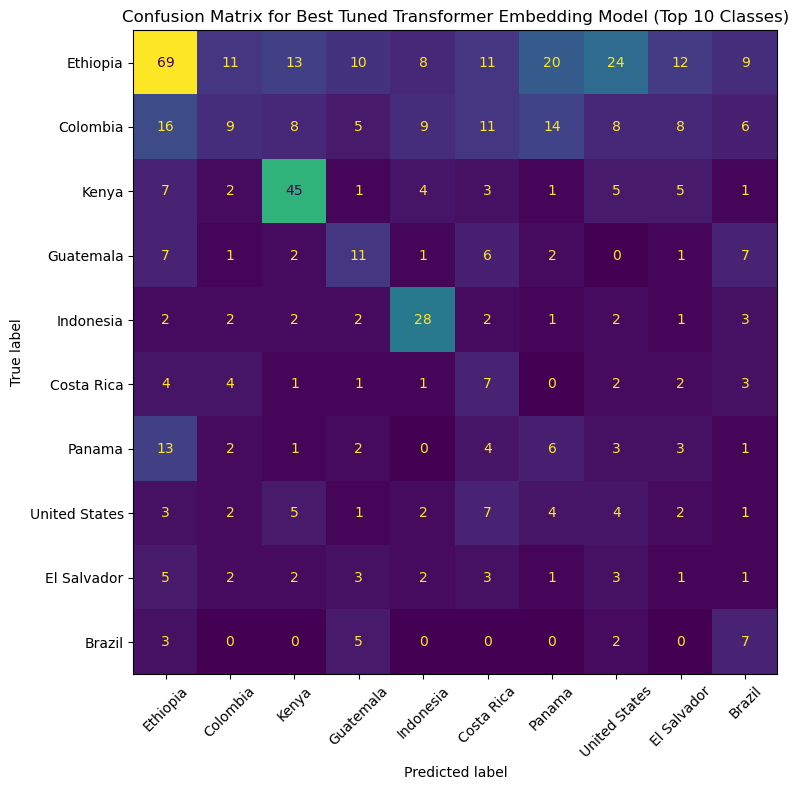

In [13]:
top_confusion_labels = y_test.value_counts().head(10).index
cm = confusion_matrix(y_test, y_test_pred_best, labels=top_confusion_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_confusion_labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix for Best Tuned Transformer Embedding Model (Top 10 Classes)')
plt.tight_layout()
plt.show()

## Training-only resampling experiments

In [14]:
def metric_row_explicit(label, y_val_true, y_val_pred, y_test_true, y_test_pred):
    val_acc = accuracy_score(y_val_true, y_val_pred)
    val_bal_acc = balanced_accuracy_score(y_val_true, y_val_pred)
    val_p, val_r, val_f1, _ = precision_recall_fscore_support(y_val_true, y_val_pred, average='macro', zero_division=0)
    test_acc = accuracy_score(y_test_true, y_test_pred)
    test_bal_acc = balanced_accuracy_score(y_test_true, y_test_pred)
    test_p, test_r, test_f1, _ = precision_recall_fscore_support(y_test_true, y_test_pred, average='macro', zero_division=0)

    return {
        'experiment': label,
        'val_accuracy': val_acc,
        'val_balanced_accuracy': val_bal_acc,
        'val_precision_macro': val_p,
        'val_recall_macro': val_r,
        'val_f1_macro': val_f1,
        'test_accuracy': test_acc,
        'test_balanced_accuracy': test_bal_acc,
        'test_precision_macro': test_p,
        'test_recall_macro': test_r,
        'test_f1_macro': test_f1,
    }

# Resampling is applied only on the training split to avoid leakage
train_df = pd.DataFrame({
    'text': X_train,
    'label': y_train.reset_index(drop=True),
})

max_train_count = train_df['label'].value_counts().max()
min_train_count = train_df['label'].value_counts().min()

oversampled_parts = []
undersampled_parts = []
for label, group in train_df.groupby('label'):
    oversampled_parts.append(group.sample(n=max_train_count, replace=True, random_state=RANDOM_STATE))
    undersampled_parts.append(group.sample(n=min_train_count, replace=False, random_state=RANDOM_STATE))

train_over = pd.concat(oversampled_parts, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
train_under = pd.concat(undersampled_parts, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print('Original training rows:', len(train_df))
print('Oversampled training rows:', len(train_over))
print('Undersampled training rows:', len(train_under))

Original training rows: 5205
Oversampled training rows: 34925
Undersampled training rows: 600


In [15]:
def train_and_predict_for_resampling(train_texts, train_labels, val_texts, test_texts, params):
    X_train_vec, X_val_vec, X_test_vec = encode_transformer_split(params['embedding_name'], train_texts, val_texts, test_texts)
    model = build_classifier(params['model_name'], params['C'], params['feature_reduction'])
    model.fit(X_train_vec, train_labels)
    y_val_pred = model.predict(X_val_vec)
    y_test_pred = model.predict(X_test_vec)
    return y_val_pred, y_test_pred

y_val_pred_original, y_test_pred_original = train_and_predict_for_resampling(X_train, y_train, X_val, X_test, best_params)
y_val_pred_over, y_test_pred_over = train_and_predict_for_resampling(train_over['text'].tolist(), train_over['label'], X_val, X_test, best_params)
y_val_pred_under, y_test_pred_under = train_and_predict_for_resampling(train_under['text'].tolist(), train_under['label'], X_val, X_test, best_params)


In [16]:
resampling_results_df = pd.DataFrame([
    metric_row_explicit('Class weighting only', y_val, y_val_pred_original, y_test, y_test_pred_original),
    metric_row_explicit('Class weighting + oversampled training set', y_val, y_val_pred_over, y_test, y_test_pred_over),
    metric_row_explicit('Class weighting + undersampled training set', y_val, y_val_pred_under, y_test, y_test_pred_under),
]).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)

resampling_results_df

,experiment,val_accuracy,val_balanced_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,test_accuracy,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,Class weighting only,0.173835,0.117034,0.112019,0.117034,0.105021,0.184588,0.145363,0.124143,0.145363,0.121643
1,Class weighting + oversampled training set,0.143369,0.094207,0.099472,0.094207,0.084838,0.138889,0.135535,0.112601,0.135535,0.110170
2,Class weighting + undersampled training set,0.084229,0.103870,0.081790,0.103870,0.068604,0.086918,0.107868,0.081460,0.107868,0.066996
